# Load Dataset

In [ ]:
!pip uninstall -y torch torchvision

Found existing installation: torch 2.11.0+cpu
Uninstalling torch-2.11.0+cpu:
  Successfully uninstalled torch-2.11.0+cpu
Found existing installation: torchvision 0.26.0+cpu
Uninstalling torchvision-0.26.0+cpu:
  Successfully uninstalled torchvision-0.26.0+cpu


In [ ]:
!pip install torch==2.11.0 torchvision==0.26.0 --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
  Using cached https://download-r2.pytorch.org/whl/cu128/torchvision-0.26.0%2Bcu128-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
Using cached https://download-r2.pytorch.org/whl/cu128/torchvision-0.26.0%2Bcu128-cp312-cp312-manylinux_2_28_x86_64.whl (8.1 MB)


In [ ]:
import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.11.0+cu128
torchvision: 0.26.0+cu128


In [ ]:
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

DATA_PATH = "/content/drive/MyDrive/Hugging Face Projects/Emotion Analysis Project/data/cleaned/emotion_cleaned"

In [ ]:
from datasets import load_from_disk

dataset=load_from_disk(DATA_PATH)

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 15939
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1990
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1989
    })
})

# define class labels

In [ ]:
labels_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise",
}

In [ ]:
id2Label=labels_map

label2id={
    label:id
    for id, label in id2Label.items()
}
print(label2id)

{'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}


# Load tokenizer

We will use distilbert-base-uncased

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## Check 1 example

In [ ]:
text=dataset['train'][0]['text']
print(text)

i didnt feel humiliated


In [ ]:
tokens=tokenizer.tokenize(text)
print(tokens)

['i', 'didn', '##t', 'feel', 'humiliated']


In [ ]:
token_ids=tokenizer.convert_tokens_to_ids(tokens)
print(token_ids)

[1045, 2134, 2102, 2514, 26608]


In [ ]:
encoded=tokenizer(text)
print(encoded)

{'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


These are Vocabulary IDs


# Tokenize the whole dataset

In [ ]:
def tokenize(batch):
    return tokenizer(batch['text'], truncation=True)
    # we will use padding in data collator

In [ ]:
tokenized_dataset=dataset.map(tokenize, batched=True)

# Inspect the tokenized dataset

In [ ]:
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15939
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1990
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1989
    })
})


In [ ]:
tokenized_dataset["train"][0]

{'text': 'i didnt feel humiliated',
 'label': 0,
 'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

# Prepare the label mappings

In [ ]:
id2label = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise",
}

label2id = {
    label: id
    for id, label in id2label.items()
}

# load Model

In [ ]:
from transformers import AutoModelForSequenceClassification

model=AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=6, id2label=id2label, label2id=label2id)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
print(model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


```
DistilBERT representation
        ↓
     768 values
        ↓
   Linear layer
        ↓
     6 values
        ↓
sadness / joy / love / anger / fear / surprise
```

# baseline prediction

#### use one example

In [ ]:
text=dataset['test'][0]['text']
label=dataset['test'][0]['label']
print(f"Test: {text}")
print(f"Actual : {id2label[label]}")

Test: im feeling rather rotten so im not very ambitious right now
Actual : sadness


#### tokenize

In [ ]:
inputs=tokenizer(text, return_tensors='pt')

#### put the model in evaluation mode and run it

In [ ]:
import torch
model.eval()

with torch.no_grad():
    outputs=model(**inputs)
    logits=outputs.logits
    print(logits)
    print(logits.shape)

tensor([[ 0.0343, -0.0217, -0.0605,  0.0902, -0.0235, -0.1634]])
torch.Size([1, 6])


In [ ]:
probabilities=torch.softmax(logits, dim=-1)
print(probabilities)
print(probabilities.sum())

tensor([[0.1761, 0.1666, 0.1602, 0.1863, 0.1662, 0.1446]])
tensor(1.0000)


It's not confident on any choice at all!

In [ ]:
predicted_label=torch.argmax(probabilities, dim=-1).item()
print("Predicted: ", id2label[predicted_label])

Predicted:  anger


Even though it guessed it right, it is not confident at all! We need to train it to make it confident!

# Dynamic padding

In [ ]:
from transformers import DataCollatorWithPadding

data_collator=DataCollatorWithPadding(
    tokenizer=tokenizer
)

This will dynamically pad each batch to the longest sequence in that batch.

# Remove the raw text column

The model doesn't need the original text during training.

In [ ]:
tokenized_dataset=tokenized_dataset.remove_columns(['text'])
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15939
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1990
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1989
    })
})


# Define evaluation metrics

In [ ]:
! pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


In [ ]:
import evaluate
accuracy=evaluate.load("accuracy")
f1=evaluate.load("f1")

In [ ]:
import numpy as np

def compute_metrics(eval_pred):
    logits, labels=eval_pred
    predictions=np.argmax(logits, axis=-1)

    accuracy_result=accuracy.compute(
        predictions=predictions,
        references=labels
    )
    f1_result=f1.compute(
        predictions=predictions,
        references=labels,
        average='weighted'
    )

    return {
         "accuracy": accuracy_result["accuracy"],
        "f1": f1_result["f1"]
        }


We're using weighted F1 because our classes aren't equally represented.

# Training configuration

In [ ]:
from transformers import TrainingArguments

training_args=TrainingArguments(
    output_dir="./emotion-distilbert",
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,
    weight_decay=0.01,

    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to='none'
)

What we're telling it
learning_rate = 2e-5

How aggressively we update the model.

batch_size = 16

16 examples per GPU at a time.

epochs = 3

The model sees the training dataset three times.

weight_decay = 0.01

Regularization to help reduce overfitting.

eval_strategy = "epoch"

Evaluate after every epoch.

load_best_model_at_end = True

After training, restore the checkpoint that performed best on validation F1.

# Create the Trainer

In [ ]:
from transformers import Trainer

trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Now the whole pipeline is connected:
```
                 TRAINER
                    │
       ┌────────────┼────────────┐
       ↓            ↓            ↓
   Dataset       DistilBERT    Metrics
       ↓            ↓            ↓
   batches      predictions    accuracy/F1
       └────────────┼────────────┘
                    ↓
                 training

# Train it

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.222514,0.201318,0.929613,0.928680
2,0.129115,0.175328,0.931121,0.930784
3,0.087581,0.171226,0.934641,0.934307


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2991, training_loss=0.24636420323592848, metrics={'train_runtime': 266.3049, 'train_samples_per_second': 179.557, 'train_steps_per_second': 11.231, 'total_flos': 580782124606968.0, 'train_loss': 0.24636420323592848, 'epoch': 3.0})

# Evaluation

## Get predictions from the test set

In [ ]:
predictions=trainer.predict(tokenized_dataset["test"])

In [ ]:
import numpy as np
logits=predictions.predictions
true_labels=predictions.label_ids
pred_labels=np.argmax(logits, axis=-1)

In [ ]:
print("Logits shape:", logits.shape)
print("True labels:", true_labels.shape)
print("Predicted labels:", pred_labels.shape)

Logits shape: (1989, 6)
True labels: (1989,)
Predicted labels: (1989,)


## Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(true_labels, pred_labels)
print(cm)

[[567   4   0   7   1   0]
 [  1 655  27   3   1   3]
 [  0  25 130   2   0   0]
 [ 10   4   0 254   6   0]
 [  6   0   0   6 205   7]
 [  3   1   0   0  13  48]]


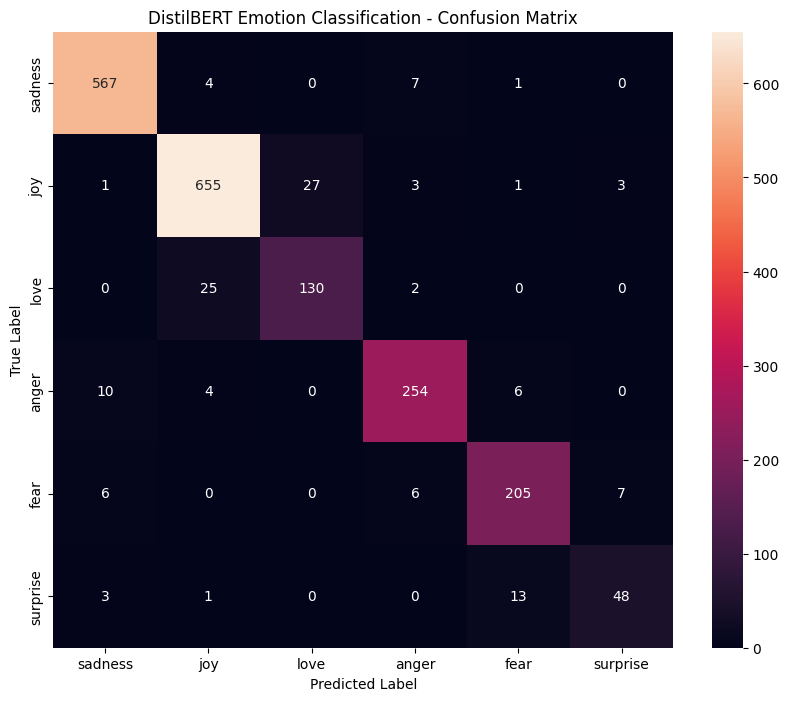

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',xticklabels=list(id2label.values()),
    yticklabels=list(id2label.values()))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DistilBERT Emotion Classification - Confusion Matrix")

plt.show()

Rows = actual emotion

Columns = model prediction

## Per-class Precision / Recall / F1

In [ ]:
from sklearn.metrics import classification_report

report=classification_report(
    true_labels,
    pred_labels,
    target_names=list(id2label.values()),
)
print(report)

              precision    recall  f1-score   support

     sadness       0.97      0.98      0.97       579
         joy       0.95      0.95      0.95       690
        love       0.83      0.83      0.83       157
       anger       0.93      0.93      0.93       274
        fear       0.91      0.92      0.91       224
    surprise       0.83      0.74      0.78        65

    accuracy                           0.93      1989
   macro avg       0.90      0.89      0.90      1989
weighted avg       0.93      0.93      0.93      1989



## Turn the report into a DataFrame

In [ ]:
import pandas as pd

report_dict=classification_report(
    true_labels,
    pred_labels,
    target_names=list(id2label.values()),
    output_dict=True
)
report_df=pd.DataFrame(report_dict).transpose()
print(report_df)

              precision    recall  f1-score      support
sadness        0.965928  0.979275  0.972556   579.000000
joy            0.950653  0.949275  0.949964   690.000000
love           0.828025  0.828025  0.828025   157.000000
anger          0.933824  0.927007  0.930403   274.000000
fear           0.907080  0.915179  0.911111   224.000000
surprise       0.827586  0.738462  0.780488    65.000000
accuracy       0.934641  0.934641  0.934641     0.934641
macro avg      0.902183  0.889537  0.895424  1989.000000
weighted avg   0.934173  0.934641  0.934307  1989.000000


In [ ]:
class_metrics = report_df.iloc[:6]

print(class_metrics)

          precision    recall  f1-score  support
sadness    0.965928  0.979275  0.972556    579.0
joy        0.950653  0.949275  0.949964    690.0
love       0.828025  0.828025  0.828025    157.0
anger      0.933824  0.927007  0.930403    274.0
fear       0.907080  0.915179  0.911111    224.0
surprise   0.827586  0.738462  0.780488     65.0


## Find the actual mistakes

Convert the test split to pandas:

In [ ]:
test_df = dataset["test"].to_pandas()

Add predictions:

In [ ]:
test_df["true_label"] = [
    id2label[label]
    for label in true_labels
]

test_df["pred_label"] = [
    id2label[label]
    for label in pred_labels
]

Now identify mistakes:

In [ ]:
errors = test_df[
    test_df["true_label"] != test_df["pred_label"]
].copy()

Check how many:

In [ ]:
print("Total test examples:", len(test_df))
print("Incorrect predictions:", len(errors))
print("Error rate:", len(errors) / len(test_df))

Total test examples: 1989
Incorrect predictions: 130
Error rate: 0.06535947712418301


## MOST COMMON CONFUSIONS


In [ ]:
error_pairs = (
    errors
    .groupby(["true_label", "pred_label"])
    .size()
    .sort_values(ascending=False)
)

print(error_pairs)


true_label  pred_label
joy         love          27
love        joy           25
surprise    fear          13
anger       sadness       10
fear        surprise       7
sadness     anger          7
anger       fear           6
fear        anger          6
            sadness        6
anger       joy            4
sadness     joy            4
surprise    sadness        3
joy         anger          3
            surprise       3
love        anger          2
joy         sadness        1
            fear           1
sadness     fear           1
surprise    joy            1
dtype: int64


## CONFIDENCE

In [ ]:
probabilities = torch.softmax(
    torch.tensor(logits),
    dim=-1
).numpy()

confidence = probabilities.max(axis=1)

test_df["confidence"] = confidence


## HIGH-CONFIDENCE ERRORS


In [ ]:
high_confidence_errors = (
    test_df[
        test_df["true_label"] != test_df["pred_label"]
    ]
    .sort_values("confidence", ascending=False)
)

print(
    high_confidence_errors[
        ["text", "true_label", "pred_label", "confidence"]
    ].head(20)
)

                                                   text true_label pred_label  \
810   whenever i put myself in others shoes and try ...      anger        joy   
1917  i feel inside cause life is like a game someti...       fear    sadness   
193   i really dont like quinn because i feel like s...      anger    sadness   
1367  i walked to school he felt the bounce in his s...       love        joy   
1523  i actually was in a meeting last week where so...      anger    sadness   
1372  i cannot even begin to express in words the de...   surprise    sadness   
422   i feel unprotected a class post count link hre...    sadness       fear   
1012  i know is that she s here and i m so thankful ...    sadness        joy   
1421  i felt a stronger wish to be free from self ch...    sadness        joy   
125   i feel very mislead by someone that i really r...       love      anger   
1866          i need a break or im feeling stressed out      anger    sadness   
654   i was playing a sport 

# inference

inference pipeline

```
New text
   ↓
Tokenizer
   ↓
input_ids + attention_mask
   ↓
Fine-tuned DistilBERT
   ↓
logits
   ↓
softmax
   ↓
probabilities
   ↓
highest probability
   ↓
emotion

```



In [ ]:
from transformers import pipeline

classifier=pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
)

In [ ]:
classifier("I finally achieved something I've been working toward!")

[{'label': 'joy', 'score': 0.9952459931373596}]

# Save the trained model

In [ ]:
model_path='./drive/MyDrive/Emotion_Distil-bert'
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./drive/MyDrive/Emotion_Distil-bert/tokenizer_config.json',
 './drive/MyDrive/Emotion_Distil-bert/tokenizer.json')

# load the model again

In [ ]:
model_path='./drive/MyDrive/Emotion_Distil-bert'


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_path
)

tokenizer = AutoTokenizer.from_pretrained(
    model_path
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

## create new pipleline

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer
)

In [ ]:
classifier("I am extremely happy that everything finally worked!")

[{'label': 'joy', 'score': 0.998863697052002}]

In [ ]:
classifier("I am extremely happy that everything finally worked!")

[{'label': 'joy', 'score': 0.998863697052002}]

In [ ]:
classifier("I wanna die")

[{'label': 'sadness', 'score': 0.4157509207725525}]

In [ ]:
classifier("I want to die")

[{'label': 'sadness', 'score': 0.6760751605033875}]

# Push to hugging face

In [ ]:
!pip install -U huggingface_hub

KeyboardInterrupt: 

In [ ]:
from huggingface_hub import login

login()

In [ ]:
model.push_to_hub("distilbert-emotion-classifier")
tokenizer.push_to_hub("distilbert-emotion-classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...pq4z1h4/model.safetensors:   0%|          |  575kB /  268MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/nmfairuz/distilbert-emotion-classifier/commit/4d92046d2e0cb251f97763e9b46c75dcf57cbdeb', commit_message='Upload tokenizer', commit_description='', oid='4d92046d2e0cb251f97763e9b46c75dcf57cbdeb', pr_url=None, repo_url=RepoUrl('https://huggingface.co/nmfairuz/distilbert-emotion-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='nmfairuz/distilbert-emotion-classifier'), pr_revision=None, pr_num=None)

# Load from HF hub

In [ ]:
from transformers import pipeline

classifier=pipeline(
    "text-classification",
    model='nmfairuz/distilbert-emotion-classifier'
)

classifier("I am so happy that i wanna die")

config.json:   0%|          | 0.00/888 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

[{'label': 'joy', 'score': 0.9987749457359314}]

In [ ]:
classifier("What do u think, am i mad?")

[{'label': 'anger', 'score': 0.9979875087738037}]

In [ ]:
classifier("What do u think?")

[{'label': 'anger', 'score': 0.5772998929023743}]

In [ ]:
classifier("What is your name?")

[{'label': 'anger', 'score': 0.6918202638626099}]

In [ ]:
classifier(["What is your favorite color?","Where do you live?","How are you doing?","I love this!","I am terrified.","I am furious!"])

[{'label': 'joy', 'score': 0.6251820921897888},
 {'label': 'anger', 'score': 0.5215882658958435},
 {'label': 'joy', 'score': 0.379268079996109},
 {'label': 'anger', 'score': 0.8472135066986084},
 {'label': 'fear', 'score': 0.9973879456520081},
 {'label': 'anger', 'score': 0.9973209500312805}]

The model was trained to classify emotional utterances into six emotion classes, so it isn't designed to detect neutral text. Questions that don't express one of the six emotions are therefore forced into the closest learned class.